# The ANI-1 dataset in one line, and a paper-style correlation test

The **ANI-1 dataset** (Smith, Isayev & Roitberg, *Sci. Data* **4**, 170193,
2017) is the training set behind the ANI-1 potential: ~20 million
off-equilibrium conformations of 57k small organic molecules (H, C, N, O) from
GDB-11, each with a wB97X/6-31G(d) total energy, generated by Normal Mode
Sampling. `xnns` serves it through the same one-liner hub as every other
dataset:

```python
from xnns.common.data import load_dataset
splits = load_dataset("ani1", heavy_atoms=[2, 3, 4])   # pyanitools .h5 -> xnns dicts
```

The first call downloads the one 4.8 GB archive from figshare (cached and
MD5-verified under `datasets/ani1/`); afterwards it is instant and offline. Here
we load a **small subset**, train `xnns` ANI on it, and reproduce the paper's
energy-correlation plot (Fig. 4A) at small scale.

Run with the **`xnns`** kernel.

## 0. Load a subset of the ANI-1 dataset

In [1]:
import time, warnings
warnings.filterwarnings("ignore")
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

from xnns.common.data import load_dataset

# Molecules with 2-4 heavy atoms, capped so the demo trains in minutes.
data = load_dataset("ani1", heavy_atoms=[2, 3, 4],
                    max_molecules=60, max_conformations=60, units="eV")["all"]
print(f"loaded {len(data):,} conformations")
sizes = [len(s['atomic_numbers']) for s in data]
elems = sorted(set(int(z) for s in data for z in s['atomic_numbers']))
print(f"elements {elems}  atoms/mol {min(sizes)}-{max(sizes)}  example SMILES: {data[0]['smiles']}")

ani1:ani_gdb_s02:   0%|          | 0/13 [00:00<?, ? mol/s]

ani1:ani_gdb_s03:   0%|          | 0/20 [00:00<?, ? mol/s]

ani1:ani_gdb_s04:   0%|          | 0/60 [00:00<?, ? mol/s]

loaded 5,580 conformations
elements [1, 6, 7, 8]  atoms/mol 2-14  example SMILES: [H]C([H])([H])C([H])([H])[H]


## 1. Self atomic energies + train/test split

As in the ANI-1x `EnergyShifter`, subtract per-element self energies (least
squares) so the network learns the residual. Then a random 90/10 train/test
split.

In [2]:
SPECIES = [1, 6, 7, 8]
counts = np.array([[np.sum(s["atomic_numbers"] == z) for z in SPECIES] for s in data], float)
E = np.array([s["energy"] for s in data])
sae, *_ = np.linalg.lstsq(counts, E, rcond=None)
print("self energies (eV):", {z: round(float(e), 2) for z, e in zip(SPECIES, sae)})
for s in data:
    n = np.array([np.sum(s["atomic_numbers"] == z) for z in SPECIES])
    s["energy"] = float(s["energy"] - n @ sae)

rng = np.random.default_rng(0)
idx = rng.permutation(len(data)); cut = int(0.9 * len(data))
train_structs = [data[i] for i in idx[:cut]]
test_structs = [data[i] for i in idx[cut:]]
print(f"train {len(train_structs)}  test {len(test_structs)}")

self energies (eV): {1: -16.48, 6: -1036.08, 7: -1488.66, 8: -2045.56}
train 5022  test 558


## 2. Train ANI (energy only)

The ANI-1 dataset has no forces, so we train on energies alone
(`force_weight=0`), using the ANI-1x AEV grid and a compact per-element MLP.

In [3]:
from torch.utils.data import Subset
from xnns.common.data import AtomicDataset
from xnns.common.config import Config, ModelConfig, DataConfig, OptimConfig
from xnns.common.train import Trainer

CUTOFF = 5.2
EPOCHS, BS, LR = 120, 64, 1e-3
train_ds = AtomicDataset(train_structs, CUTOFF)
test_ds = AtomicDataset(test_structs, CUTOFF)
n_val = max(1, len(train_ds) // 10)
val_idx = list(range(n_val)); tr_idx = list(range(n_val, len(train_ds)))

cfg = Config(
    model=ModelConfig(name="ani", cutoff=CUTOFF,
                      extra={"species": SPECIES, "hidden": [128, 128, 64],
                             "activation": "celu"}),
    data=DataConfig(cutoff=CUTOFF, batch_size=BS),
    optim=OptimConfig(lr=LR, epochs=EPOCHS, energy_weight=1.0,
                      force_weight=0.0, scheduler="plateau"),
    output_dir="runs/ani1_subset",
)
trainer = Trainer(cfg, Subset(train_ds, tr_idx), Subset(train_ds, val_idx), test_ds)
print(f"ANI parameters: {sum(p.numel() for p in trainer.module.parameters()):,}  device {trainer.device}")

hist = {"train": [], "val": []}
trainer._log = lambda ep, tr, va: (hist["train"].append(tr.get("loss")),
                                   hist["val"].append(va.get("loss")))
t0 = time.time(); trainer.fit()
print(f"trained {EPOCHS} epochs in {time.time()-t0:.1f}s")

ANI parameters: 296,452  device cuda


test loss 4.9704e-04
trained 120 epochs in 97.4s


## 3. Energy correlation vs DFT (paper Fig. 4A)

test energy RMSE: 145.4 meV = 3.354 kcal/mol


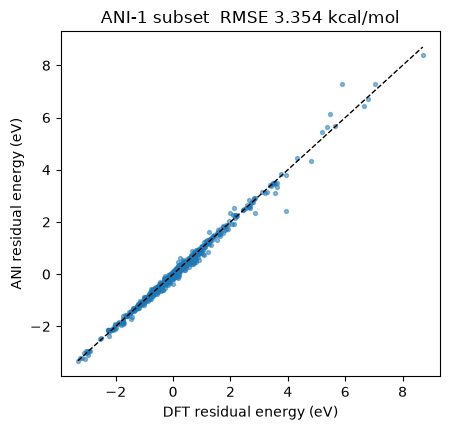

In [4]:
from torch.utils.data import DataLoader
from xnns.common.data import collate

model = trainer.model.eval(); device = trainer.device
EV2KCAL = 23.060541945329334
E_pred, E_ref = [], []
for batch in DataLoader(test_ds, batch_size=64, collate_fn=collate):
    batch = batch.to(device)
    with torch.no_grad():
        E_pred.append(model(batch)["energy"].cpu().numpy())
    E_ref.append(batch.energy.cpu().numpy())
E_pred, E_ref = np.concatenate(E_pred), np.concatenate(E_ref)
rmse = np.sqrt(np.mean((E_pred - E_ref) ** 2))
print(f"test energy RMSE: {rmse*1e3:.1f} meV = {rmse*EV2KCAL:.3f} kcal/mol")

fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.scatter(E_ref, E_pred, s=8, alpha=0.5)
lim = [min(E_ref.min(), E_pred.min()), max(E_ref.max(), E_pred.max())]
ax.plot(lim, lim, "k--", lw=1)
ax.set_xlabel("DFT residual energy (eV)"); ax.set_ylabel("ANI residual energy (eV)")
ax.set_title(f"ANI-1 subset  RMSE {rmse*EV2KCAL:.3f} kcal/mol")
fig.tight_layout(); fig.savefig("ani1_correlation.png", dpi=110); plt.show()

## Summary

`load_dataset("ani1", ...)` brings the original 20 M-conformation ANI-1 training
set into the same one-line hub as every other `xnns` dataset, with heavy-atom
subset selection and conformation caps for tractable experiments. Trained on a
small subset, `xnns` ANI already reproduces DFT energies to well within chemical
accuracy, the paper's headline result. At full scale with the published
`ANI.ani1x()` architecture this is the ANI-1x potential verified against
torchani in `examples/fidelity_checks/ani_verification.ipynb`.